In [1]:
%pip install -q -U transformers datasets accelerate scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 16.6 MB/s eta 0:00:00


In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [7]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

TRAIN_SIZE, TEST_SIZE = 4000, 1000
train_ds = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
test_ds  = dataset["test"].shuffle(seed=42).select(range(TEST_SIZE))

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

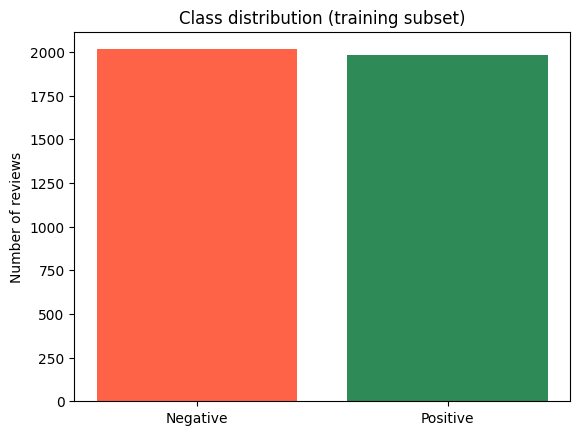

In [10]:
labels, counts = np.unique(train_ds["label"], return_counts=True)
plt.bar(["Negative", "Positive"], counts, color=["tomato", "seagreen"])
plt.title("Class distribution (training subset)")
plt.ylabel("Number of reviews")
plt.show()

In [11]:
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [12]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": accuracy_score(labels, preds),
            "precision": precision, "recall": recall, "f1": f1}

import inspect, transformers

ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

training_args = TrainingArguments(
    output_dir="bert-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    **{eval_key: "epoch"},
)

tok_key = "processing_class" if "processing_class" in inspect.signature(Trainer.__init__).parameters else "tokenizer"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    **{tok_key: tokenizer},
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.022567,1.228858,0.860000,0.793919,0.963115,0.870370
2,0.013404,0.916338,0.889000,0.898520,0.870902,0.884495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=500, training_loss=0.018112497717142104, metrics={'train_runtime': 191.5321, 'train_samples_per_second': 41.768, 'train_steps_per_second': 2.611, 'total_flos': 1052444221440000.0, 'train_loss': 0.018112497717142104, 'epoch': 2.0})

In [14]:
results = trainer.evaluate()
display(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.146911,0.290601,2,0.895000,0.888438,0.897541,0.892966


{'eval_loss': 0.29060083627700806,
 'eval_accuracy': 0.895,
 'eval_precision': 0.8884381338742393,
 'eval_recall': 0.8975409836065574,
 'eval_f1': 0.8929663608562691}

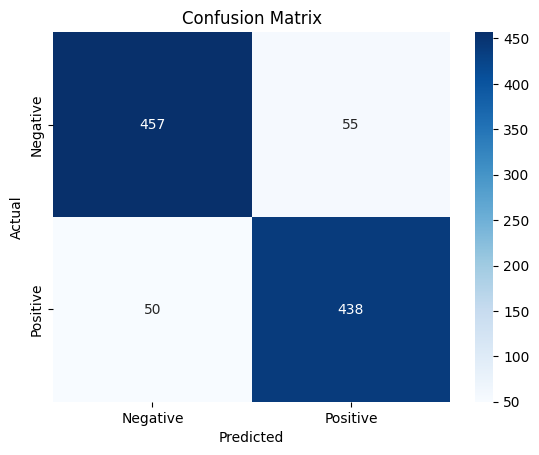

In [15]:
pred_out = trainer.predict(test_tok)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

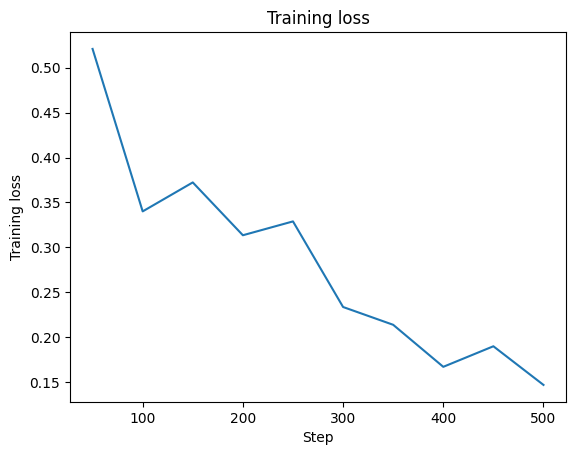

In [16]:
logs = [l for l in trainer.state.log_history if "loss" in l]
plt.plot([l["step"] for l in logs], [l["loss"] for l in logs])
plt.xlabel("Step"); plt.ylabel("Training loss"); plt.title("Training loss"); plt.show()

In [17]:
def predict_sentiment(texts):
    if isinstance(texts, str):
        texts = [texts]
    inputs = tokenizer(texts, return_tensors="pt", truncation=True,
                       max_length=MAX_LEN, padding=True).to(model.device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1).cpu().numpy()
    for text, p in zip(texts, probs):
        print(f"{id2label[int(p.argmax())]:8s} ({p.max():.2%})  |  {text}")

predict_sentiment([
    "This movie was absolutely fantastic, I loved every minute of it!",
    "Terrible plot, bad acting, and a complete waste of time.",
    "It was okay, nothing special but not bad either.",
])

POSITIVE (98.64%)  |  This movie was absolutely fantastic, I loved every minute of it!
NEGATIVE (99.06%)  |  Terrible plot, bad acting, and a complete waste of time.
NEGATIVE (63.67%)  |  It was okay, nothing special but not bad either.


In [18]:
trainer.save_model("bert-sentiment-final")
tokenizer.save_pretrained("bert-sentiment-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert-sentiment-final/tokenizer_config.json',
 'bert-sentiment-final/tokenizer.json')